<a href="https://colab.research.google.com/github/eparks8/ECGR-5105-Intro-to-ML/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3: Logistic Regression Clasification

## Imports

### Libraries

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Drive Imports
from google.colab import drive

### Data

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_diabetes = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HW3/diabetes.csv")
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df_cancer = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HW3/Cancer.csv")
df_cancer = df_cancer.drop(columns='id')
df_cancer.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Problem 1: Diabetes Classifier

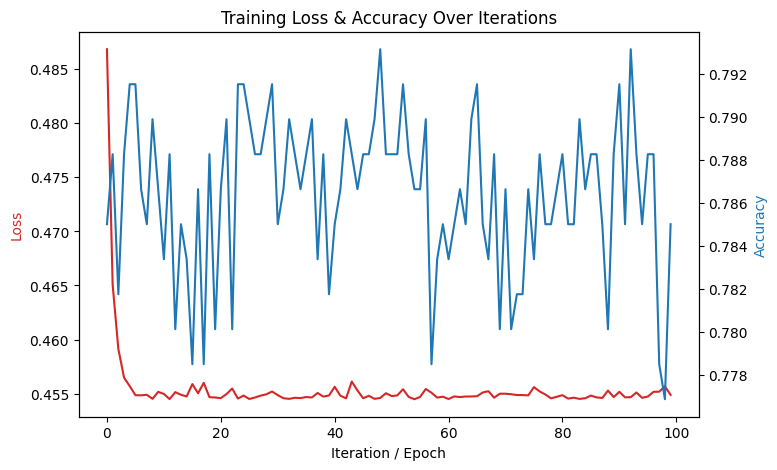

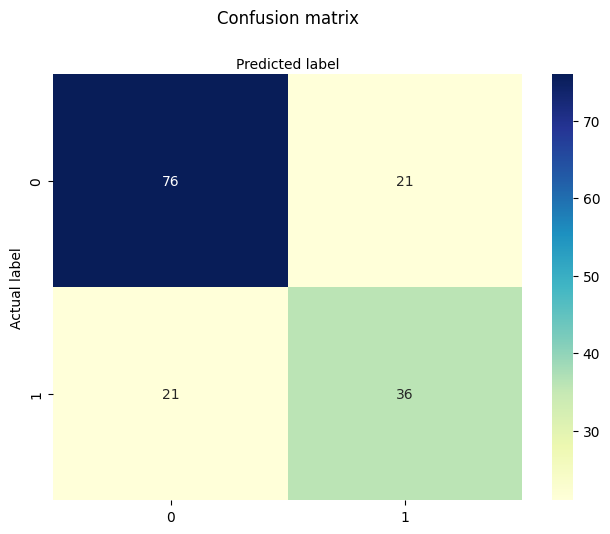



Accuracy: 0.7272727272727273

lassification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        97
           1       0.63      0.63      0.63        57

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



In [5]:
Xd_train, Xd_val, Yd_train, Yd_val = train_test_split(df_diabetes.drop(columns='Outcome'), df_diabetes['Outcome'], test_size=0.2, random_state=5105)
d_std = StandardScaler()
Xd_train = d_std.fit_transform(Xd_train)
Xd_val = d_std.transform(Xd_val)

d_model = SGDClassifier(loss='log_loss', max_iter=1, warm_start=True, learning_rate='constant', eta0=0.01, penalty=None)

d_loss_history = []
d_acc_history = []

epochs = 100
classes = [0, 1]

for epoch in range(epochs):
    # Perform a single gradient descent iteration
    d_model.partial_fit(Xd_train, Yd_train, classes=classes)

    y_pred_prob = d_model.predict_proba(Xd_train)
    y_pred = d_model.predict(Xd_train)

    d_loss_history.append(log_loss(Yd_train, y_pred_prob))
    d_acc_history.append(accuracy_score(Yd_train, y_pred))

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel('Iteration / Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(d_loss_history, color='tab:red', label='Training Loss')

ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(d_acc_history, color='tab:blue', label='Training Accuracy')

plt.title('Training Loss & Accuracy Over Iterations')
plt.show()

d_pred = d_model.predict(Xd_val)

d_confusion = confusion_matrix(Yd_val, d_pred)
d_accuracy = accuracy_score(Yd_val, d_pred)
d_report = classification_report(Yd_val, d_pred)

class_names = [0,1]
fig, ax = plt.subplots()
tickmarks = np.arange(len(class_names))
plt.xticks(tickmarks, class_names)
plt.yticks(tickmarks, class_names)
sns.heatmap(pd.DataFrame(d_confusion), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

print(f"\n\nAccuracy: {d_accuracy}")
print(f"\nlassification Report:\n{d_report}")

## Problem 2: Cancer Classifier

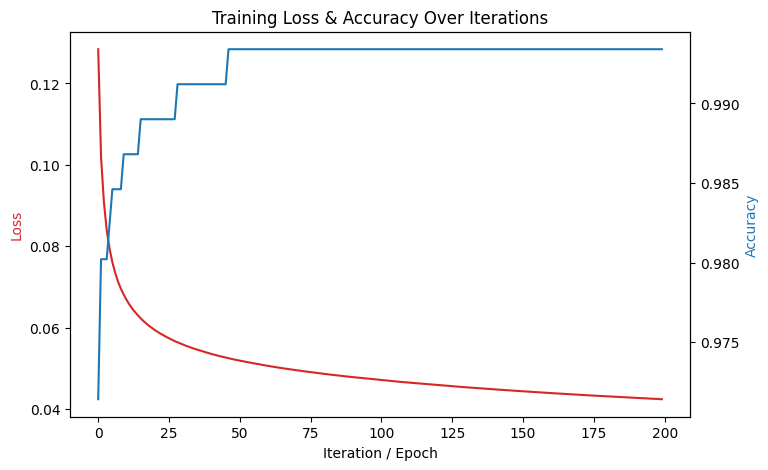

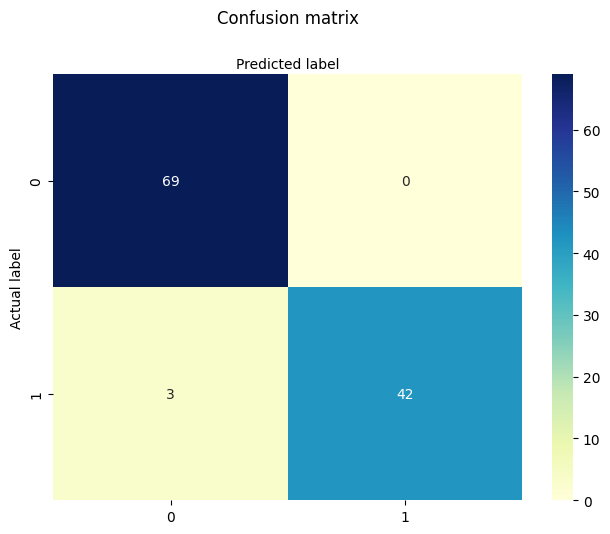



Accuracy: 0.9736842105263158

Classification Report:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        69
           M       1.00      0.93      0.97        45

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [6]:
Xc_train, Xc_val, Yc_train, Yc_val = train_test_split(df_cancer.drop(columns='diagnosis'), df_cancer['diagnosis'], test_size=0.2, random_state=5105)
c_std = StandardScaler()
Xc_train = c_std.fit_transform(Xc_train)
Xc_val = c_std.transform(Xc_val)

c_model = SGDClassifier(loss='log_loss', max_iter=1, warm_start=True, learning_rate='constant', eta0=0.01, penalty=None)

c_loss_history = []
c_acc_history = []

epochs = 200
classes = ['B', 'M']

for epoch in range(epochs):
    # Perform a single gradient descent iteration
    c_model.partial_fit(Xc_train, Yc_train, classes=classes)

    y_pred_prob = c_model.predict_proba(Xc_train)
    y_pred = c_model.predict(Xc_train)

    c_loss_history.append(log_loss(Yc_train, y_pred_prob))
    c_acc_history.append(accuracy_score(Yc_train, y_pred))

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel('Iteration / Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(c_loss_history, color='tab:red', label='Training Loss')

ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(c_acc_history, color='tab:blue', label='Training Accuracy')

plt.title('Training Loss & Accuracy Over Iterations')
plt.show()

c_pred = c_model.predict(Xc_val)

c_confusion = confusion_matrix(Yc_val, c_pred)
c_accuracy = accuracy_score(Yc_val, c_pred)
c_report = classification_report(Yc_val, c_pred)

fig, ax = plt.subplots()
tickmarks = np.arange(len(class_names))
plt.xticks(tickmarks, class_names)
plt.yticks(tickmarks, class_names)
sns.heatmap(pd.DataFrame(c_confusion), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

print(f"\n\nAccuracy: {c_accuracy}")
print(f"\nClassification Report:\n{c_report}")

## Problem 2a: Penalized Cancer Classifier

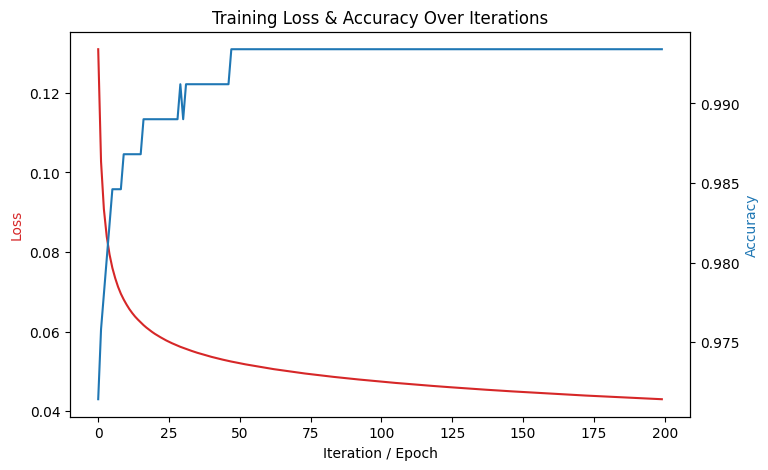

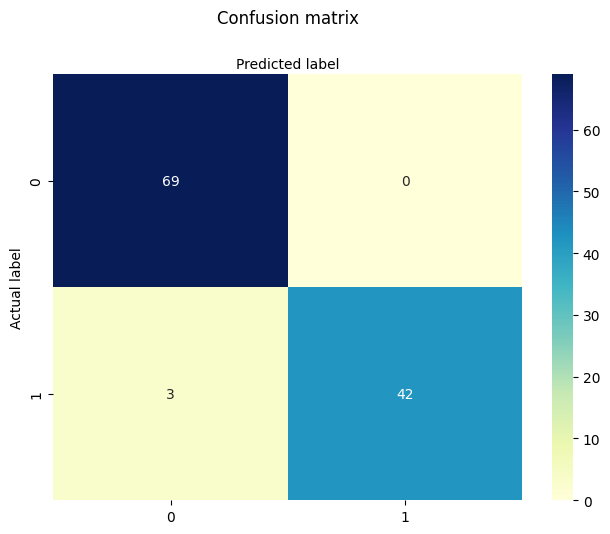



Accuracy: 0.9736842105263158

Classification Report:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        69
           M       1.00      0.93      0.97        45

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [9]:
c_l2_model = SGDClassifier(loss='log_loss', max_iter=1, warm_start=True, learning_rate='constant', eta0=0.01, penalty='l2')

c_l2_loss_history = []
c_l2_acc_history = []

epochs = 200
classes = ['B', 'M']

for epoch in range(epochs):
    # Perform a single gradient descent iteration
    c_l2_model.partial_fit(Xc_train, Yc_train, classes=classes)

    y_pred_prob = c_l2_model.predict_proba(Xc_train)
    y_pred = c_l2_model.predict(Xc_train)

    c_l2_loss_history.append(log_loss(Yc_train, y_pred_prob))
    c_l2_acc_history.append(accuracy_score(Yc_train, y_pred))

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel('Iteration / Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(c_l2_loss_history, color='tab:red', label='Training Loss')

ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(c_l2_acc_history, color='tab:blue', label='Training Accuracy')

plt.title('Training Loss & Accuracy Over Iterations')
plt.show()

c_l2_pred = c_l2_model.predict(Xc_val)

c_l2_confusion = confusion_matrix(Yc_val, c_l2_pred)
c_l2_accuracy = accuracy_score(Yc_val, c_l2_pred)
c_l2_report = classification_report(Yc_val, c_l2_pred)

fig, ax = plt.subplots()
tickmarks = np.arange(len(class_names))
plt.xticks(tickmarks, class_names)
plt.yticks(tickmarks, class_names)
sns.heatmap(pd.DataFrame(c_l2_confusion), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

print(f"\n\nAccuracy: {c_accuracy}")
print(f"\nClassification Report:\n{c_report}")